In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
print(df.head())
print("\n")
print(df.shape)
print("\n")

print(df.info())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


(20640, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64


In [5]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
print("\nIntercept:")
print(model.intercept_)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nCoefficients")
print(coef)


Intercept:
2.0692396089424165

Coefficients
      Feature  Coefficient
0      MedInc     0.849222
1    HouseAge     0.122119
2    AveRooms    -0.299558
3   AveBedrms     0.348410
4  Population    -0.000884
5    AveOccup    -0.041698
6    Latitude    -0.893856
7   Longitude    -0.868617


In [10]:
y_pred = model.predict(X_test)

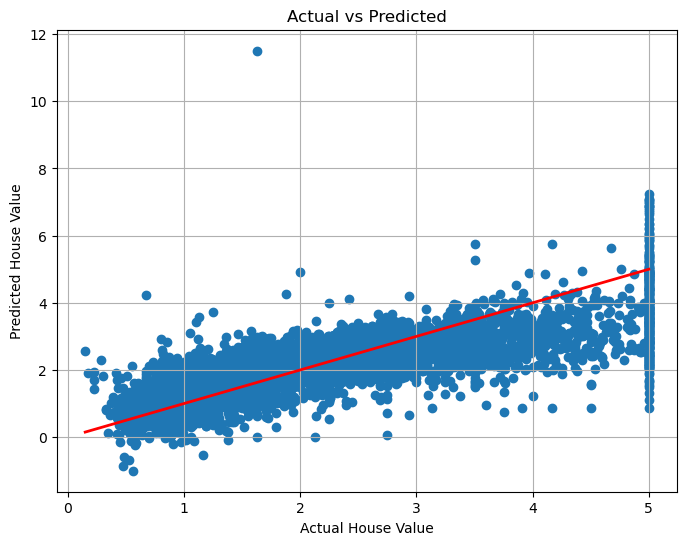

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()

In [12]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Square Error (MSE) : ", mse)

Mean Square Error (MSE) :  0.5305677824766752


### Gradient Descent

In [13]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [14]:
m = X_train.shape[0]
n = X_train.shape[1]

In [15]:
weights = np.zeros(n)
bias = 0

In [16]:
weights

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
learning_rate = 0.01
epochs = 1000

loss_history = []

In [18]:
for epoch in range(epochs):

    # Prediction
    y_pred = np.dot(X_train, weights) + bias

    # Error
    error = y_pred - y_train

    # Cost (Mean Square Error)
    loss = (1 / m) * np.sum(error ** 2)
    loss_history.append(loss)

    # Gradients
    dm = (2 / m) * np.dot(X_train.T, error)
    dc = (2 / m) * np.sum(error)

    # Update Parameters
    weights = weights - learning_rate * dm
    bias = bias - learning_rate * dc

    if epoch % 100 == 0:
        print(f"Epoch {epoch} : Loss = {loss:.5f}")

print("\nTraining Completed!")

Epoch 0 : Loss = 5.62145
Epoch 100 : Loss = 0.71493
Epoch 200 : Loss = 0.60042
Epoch 300 : Loss = 0.57858
Epoch 400 : Loss = 0.56387
Epoch 500 : Loss = 0.55315
Epoch 600 : Loss = 0.54532
Epoch 700 : Loss = 0.53959
Epoch 800 : Loss = 0.53538
Epoch 900 : Loss = 0.53229

Training Completed!


In [19]:
# Test Model using (X_test and weights)

y_pred_gd = np.dot(X_test, weights) + bias

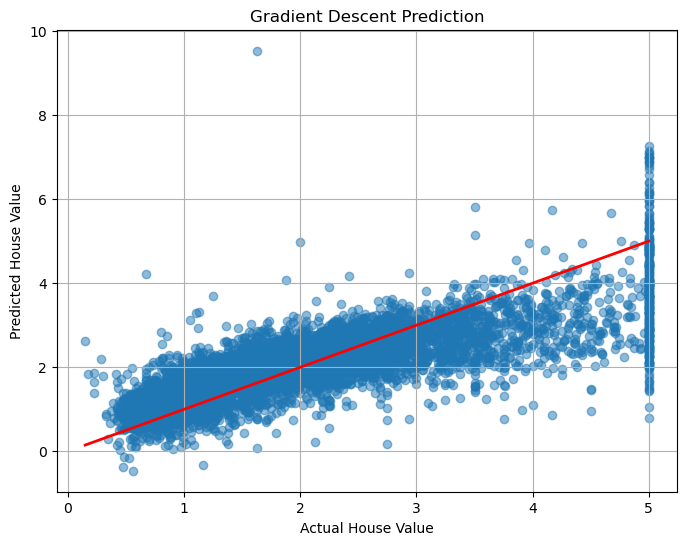

In [20]:
# Actual vs Predicted Graph

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_gd, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("Gradient Descent Prediction")

plt.grid(True)

plt.show()

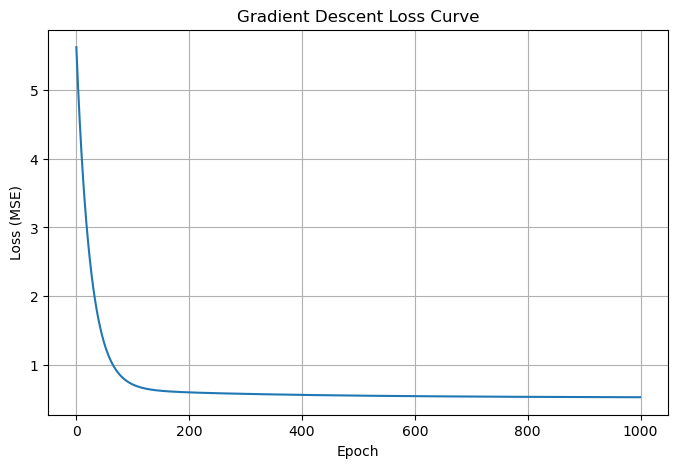

In [21]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss (MSE)")

plt.title("Gradient Descent Loss Curve")

plt.grid(True)

plt.show()

In [22]:
print("============== Comparison ==============")

comparison = pd.DataFrame({

    "Feature": X.columns,

    "Scikit-Learn": model.coef_,

    "Gradient Descent": weights

})

print(comparison)

print("\nScikit Bias :", model.intercept_)

print("Gradient Descent Bias :", bias)

============== Comparison ==============
      Feature  Scikit-Learn  Gradient Descent
0      MedInc      0.849222          0.850462
1    HouseAge      0.122119          0.149835
2    AveRooms     -0.299558         -0.250347
3   AveBedrms      0.348410          0.283469
4  Population     -0.000884          0.008904
5    AveOccup     -0.041698         -0.044353
6    Latitude     -0.893856         -0.684907
7   Longitude     -0.868617         -0.657319

Scikit Bias : 2.0692396089424165
Gradient Descent Bias : 2.0692396054599524
